# Pronóstico de Ventas de Alcohol usando RNN y LSTM

Lucho Dic| 2023 <br>
Le bonheur by Berr

Este proyecto tiene como objetivo predecir las ventas mensuales de alcohol en EE. UU. utilizando modelos de aprendizaje profundo como RNN y LSTM.
### 📊 Conjunto de Datos

- **Fuente:** Ventas mensuales de alcohol en EE. UU. (1992–2019)  
- **Columnas:**
  - `DATE`: Mes y año  
  - `S4248SM144NCEN`: Cifras de ventas (en millones de dólares)

### 📌 Aspectos Destacados del Proyecto

- Análisis de series temporales de ventas de alcohol  
- Preprocesamiento y normalización de datos  
- Generación de secuencias para aprendizaje supervisado  
- Implementación de RNN y LSTM utilizando Keras  
- Visualización de pronósticos y evaluación del rendimiento

### 🛠️ Tecnologías Utilizadas

- Python  
- Pandas, NumPy, Matplotlib  
- TensorFlow / Keras

## Import Packages

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import MinMaxScaler

## Import datasets

In [2]:
df = pd.read_csv(r"Alcohol_Sales.csv")
df_raw = df.copy()
df.head()

,DATE,S4248SM144NCEN
0,1992-01-01,3459
1,1992-02-01,3458
2,1992-03-01,4002
3,1992-04-01,4564
4,1992-05-01,4221


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   DATE            325 non-null    object
 1   S4248SM144NCEN  325 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.2+ KB


In [4]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATE            325 non-null    datetime64[ns]
 1   S4248SM144NCEN  325 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.2 KB


In [5]:
df['DATE'].iloc[0]

Timestamp('1992-01-01 00:00:00')

In [6]:
df = df.set_index('DATE')

#### Series de Tiempo

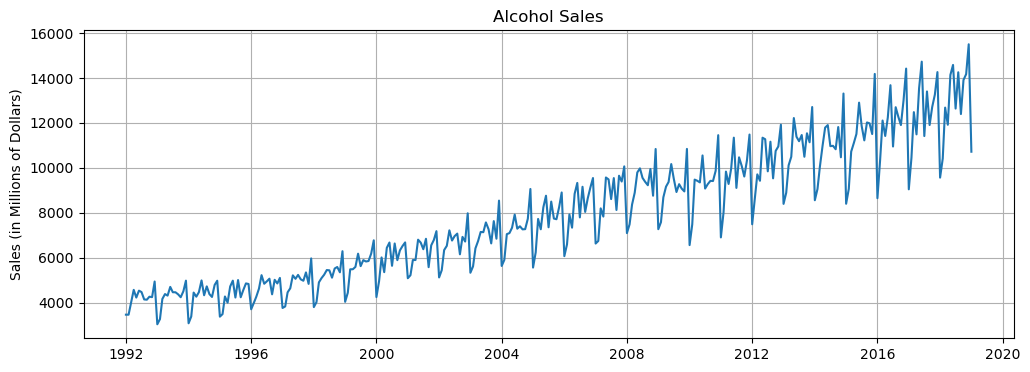

In [7]:
plt.figure(figsize=(12,4))
plt.title('Alcohol Sales')
plt.ylabel('Sales (in Millions of Dollars)')
plt.grid(True)
plt.plot(df['S4248SM144NCEN'])
plt.show()

#### Preparacion de los datos

In [8]:
y = df['S4248SM144NCEN'].values.astype(float)

test_size = 12

train_set = y[:-test_size]
test_set = y[-test_size:]

In [9]:
test_set

array([10415., 12683., 11919., 14138., 14583., 12640., 14257., 12396.,
       13914., 14174., 15504., 10718.])

##### Normalizacion

In [10]:
sc = MinMaxScaler(feature_range=(-1,1))

In [11]:
#Normalizacion train 
train_norm = sc.fit_transform(train_set.reshape(-1,1))

In [12]:
train_norm.min()

-1.0

In [13]:
train_norm.min()

-1.0

In [14]:
train_norm.mean()

-0.2041940178388313

##### Preparar datos para la red

In [15]:
# Convertir train_norm de un arreglo a un tensor

train_norm = torch.FloatTensor(train_norm).view(-1)

# Definir el tamaño de la ventana
window_size = 12

# Definir una función para crear tuplas de secuencia/etiqueta

def input_data(seq, ws):
    salida = []
    L = len(seq)
    for i in range(L - ws):
        ventana = seq[i:i + ws]
        etiqueta = seq[i + ws:i + ws + 1]
        salida.append((ventana, etiqueta))
    return salida


In [16]:
train_data = input_data(train_norm, window_size)
len(train_data)

301

In [17]:
325-12-12

301

In [18]:
train_data[0]

(tensor([-0.9268, -0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109,
         -0.8128, -0.7901, -0.7933, -0.6743]),
 tensor([-1.]))

##### Definicion del Modelo

In [19]:
class LSTMnetwork(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Agregar la capa LSTM
        self.lstm = nn.LSTM(input_size, hidden_size)
        
        # Agregar una capa totalmente conectada (fully connected)
        self.linear = nn.Linear(hidden_size, output_size)
        
        # Inicializar los estados oculto (h0) y de celda (c0)
        self.hidden = (torch.zeros(1, 1, self.hidden_size),
                       torch.zeros(1, 1, self.hidden_size))
        
    def forward(self, seq):
        # Ejecutar la LSTM sobre la secuencia de entrada
        lstm_out, self.hidden = self.lstm(seq.view(len(seq), 1, -1), self.hidden)
        
        # Pasar la salida de la LSTM por la capa lineal
        pred = self.linear(lstm_out.view(len(seq), -1))
        
        # Devolver solo la última predicción
        return pred[-1]


In [20]:
torch.manual_seed(101)

model = LSTMnetwork()
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(),lr = 0.01)

In [21]:
model

LSTMnetwork(
  (lstm): LSTM(1, 100)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

In [22]:
params = [p.numel() for p in model.parameters() if p.requires_grad]
for item in params:
    print(f'{item:>6}')

   400
 40000
   400
   400
   100
     1


In [23]:
epochs = 100  # Número de épocas


start_time = time.time()  # Registrar el tiempo de inicio

for epoch in range(epochs):
    
    for seq, y_train in train_data:
        
        optimizer.zero_grad()  # Reiniciar los gradientes del optimizador
        
        # Reinicializar los estados ocultos de la LSTM antes de cada secuencia
        model.hidden = (torch.zeros(1, 1, model.hidden_size),
                        torch.zeros(1, 1, model.hidden_size))
        
        y_pred = model(seq)  # Obtener la predicción del modelo
        
        loss = criterion(y_pred, y_train)  # Calcular la pérdida
        loss.backward()  # Propagación hacia atrás
        optimizer.step()  # Actualizar los pesos
        
    print(f'Época: {epoch+1:2} Pérdida: {loss.item():10.8f}')  # Mostrar la pérdida de la última secuencia
print(f'\n\nDuración: {time.time() - start_time: .0f} segundos')  # Mostrar el tiempo total de entrenamiento

Época:  1 Pérdida: 0.39908507
Época:  2 Pérdida: 0.37608576
Época:  3 Pérdida: 0.33052945
Época:  4 Pérdida: 0.44404289
Época:  5 Pérdida: 0.38082898
Época:  6 Pérdida: 0.38854289
Época:  7 Pérdida: 0.25963163
Época:  8 Pérdida: 0.55934799
Época:  9 Pérdida: 0.70953935
Época: 10 Pérdida: 0.24275911
Época: 11 Pérdida: 0.26368389
Época: 12 Pérdida: 0.22824778
Época: 13 Pérdida: 0.21646537
Época: 14 Pérdida: 0.20630603
Época: 15 Pérdida: 0.19803134
Época: 16 Pérdida: 0.20057151
Época: 17 Pérdida: 0.20957522
Época: 18 Pérdida: 0.21521333
Época: 19 Pérdida: 0.20972762
Época: 20 Pérdida: 0.17751968
Época: 21 Pérdida: 0.23119558
Época: 22 Pérdida: 0.16525166
Época: 23 Pérdida: 1.00995457
Época: 24 Pérdida: 0.01630971
Época: 25 Pérdida: 0.16689990
Época: 26 Pérdida: 0.00040736
Época: 27 Pérdida: 0.00302616
Época: 28 Pérdida: 0.00285594
Época: 29 Pérdida: 0.00133446
Época: 30 Pérdida: 0.00183509
Época: 31 Pérdida: 0.00250486
Época: 32 Pérdida: 0.00347671
Época: 33 Pérdida: 0.00256976
Época: 34 

In [24]:
future = 12

preds = train_norm[-window_size:].tolist()

model.eval()

for i in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                       torch.zeros(1,1,model.hidden_size))
        preds.append(model(seq).item())

In [25]:
preds[window_size:] 

[0.3696494996547699,
 0.6523829698562622,
 0.5175248384475708,
 0.9743480682373047,
 1.0014036893844604,
 0.5148904323577881,
 0.8630329370498657,
 0.44518813490867615,
 0.7123334407806396,
 0.8218883275985718,
 0.9717128276824951,
 0.2571500837802887]

In [26]:
true_predictions = sc.inverse_transform(np.array(preds[window_size:]).reshape(-1,1))
true_predictions

array([[11042.76474823],
       [12696.61418217],
       [11907.7615425 ],
       [14579.94902515],
       [14738.21088105],
       [11892.35158408],
       [13928.81116527],
       [11484.62799515],
       [13047.29446185],
       [13688.13577229],
       [14564.53418553],
       [10384.69941507]])

In [27]:
df['S4248SM144NCEN'][-12:]

DATE
2018-02-01    10415
2018-03-01    12683
2018-04-01    11919
2018-05-01    14138
2018-06-01    14583
2018-07-01    12640
2018-08-01    14257
2018-09-01    12396
2018-10-01    13914
2018-11-01    14174
2018-12-01    15504
2019-01-01    10718
Name: S4248SM144NCEN, dtype: int64

In [28]:
x = np.arange('2018-02-01','2019-02-01', dtype='datetime64[M]').astype('datetime64[D]')
x

array(['2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01',
       '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01',
       '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01'],
      dtype='datetime64[D]')

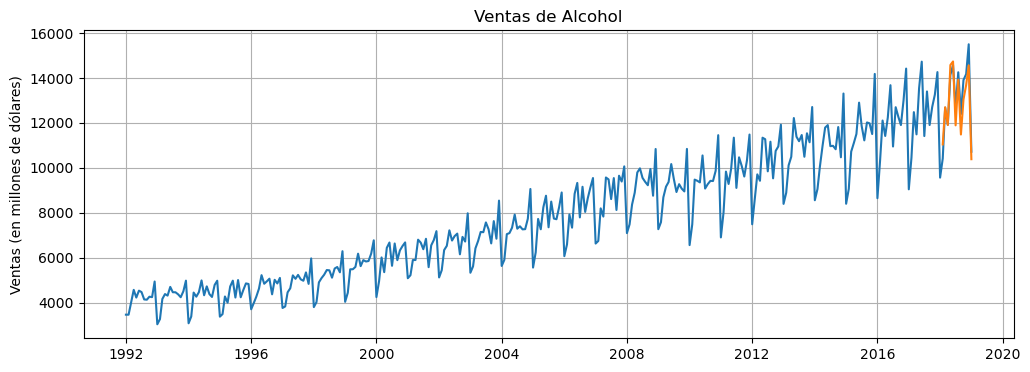

In [29]:
plt.figure(figsize=(12,4))  
plt.title('Ventas de Alcohol')  #
plt.ylabel('Ventas (en millones de dólares)')  
plt.grid(True)  

# Graficar las ventas reales
plt.plot(df['S4248SM144NCEN'])

# Graficar las predicciones del modelo
plt.plot(x, true_predictions)

plt.show()

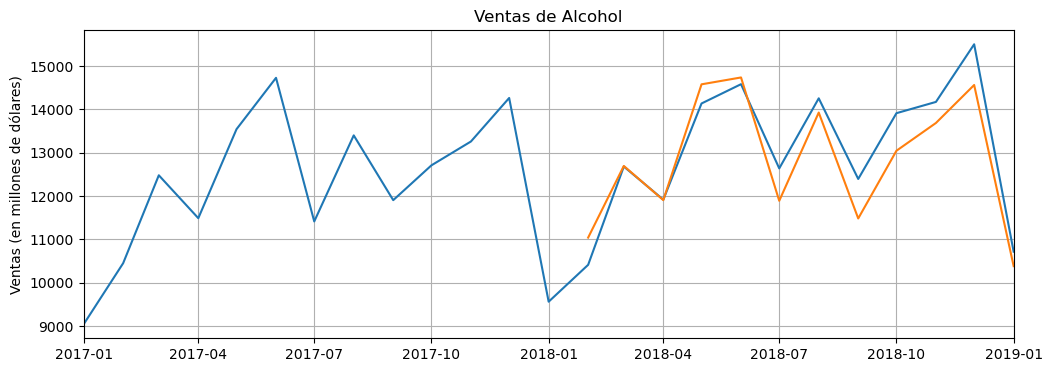

In [30]:
plt.figure(figsize=(12, 4))  
plt.title('Ventas de Alcohol')  
plt.ylabel('Ventas (en millones de dólares)') 
plt.grid(True)  
plt.autoscale(axis='x', tight=True) 

# Graficar los datos reales desde enero de 2017 en adelante
plt.plot(df['S4248SM144NCEN']['2017-01-01':])

# Graficar las predicciones del modelo
plt.plot(x, true_predictions)

plt.show()  # Mostrar el gráfico


##### Pronosticando hacia un futuro desconocido

In [31]:
epochs = 100  

model.train()  # Poner el modelo en modo de entrenamiento

# Normalizar los datos de salida (target)
y_norm = sc.fit_transform(y.reshape(-1,1))
y_norm = torch.FloatTensor(y_norm).view(-1)

# Crear todas las secuencias y etiquetas a partir de los datos normalizados
all_data = input_data(y_norm, window_size)

start_time = time.time()  

for epoch in range(epochs):  
    
    for seq, y_train in all_data:  
        
        optimizer.zero_grad()  
        
        # Reinicializar los estados ocultos de la LSTM
        model.hidden = (torch.zeros(1, 1, model.hidden_size),
                        torch.zeros(1, 1, model.hidden_size))
        
        y_pred = model(seq)  # Obtener la predicción del modelo
        
        loss = criterion(y_pred, y_train)  
        loss.backward()  
        optimizer.step()  
        
    # Mostrar la pérdida al final de cada época
    print(f'Época: {epoch+1:2} Pérdida: {loss.item():10.8f}')
    
# Mostrar duración total del entrenamiento
print(f'\n\nDuración: {time.time() - start_time: .0f} segundos')

Época:  1 Pérdida: 0.00285222
Época:  2 Pérdida: 0.00137643
Época:  3 Pérdida: 0.00012868
Época:  4 Pérdida: 0.00068680
Época:  5 Pérdida: 0.00008653
Época:  6 Pérdida: 0.00927845
Época:  7 Pérdida: 0.00186481
Época:  8 Pérdida: 0.00026387
Época:  9 Pérdida: 0.00032049
Época: 10 Pérdida: 0.00034437
Época: 11 Pérdida: 0.00029657
Época: 12 Pérdida: 0.07351188
Época: 13 Pérdida: 0.00053113
Época: 14 Pérdida: 0.00012015
Época: 15 Pérdida: 0.00003425
Época: 16 Pérdida: 0.00004966
Época: 17 Pérdida: 0.00009706
Época: 18 Pérdida: 0.00072252
Época: 19 Pérdida: 0.00099278
Época: 20 Pérdida: 0.00104660
Época: 21 Pérdida: 0.00001895
Época: 22 Pérdida: 0.00173847
Época: 23 Pérdida: 0.00093501
Época: 24 Pérdida: 0.00041792
Época: 25 Pérdida: 0.00148460
Época: 26 Pérdida: 0.00027036
Época: 27 Pérdida: 0.00193442
Época: 28 Pérdida: 0.00010894
Época: 29 Pérdida: 0.00001117
Época: 30 Pérdida: 0.00000174
Época: 31 Pérdida: 0.00083607
Época: 32 Pérdida: 0.00385041
Época: 33 Pérdida: 0.00023715
Época: 34 

##### Predecir los valores futuros

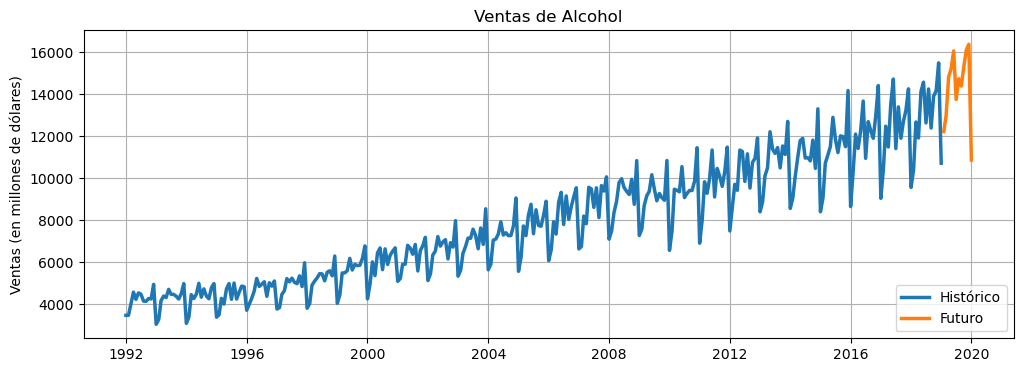

In [32]:
futuro = 12  
window_size = 12  
L = len(y)  

# Tomar la última ventana conocida y convertirla a lista
preds = train_norm[-window_size:].tolist()

model.eval()  # Poner el modelo en modo evaluación (no entrenamiento)

for i in range(futuro):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad(): 
        model.hidden = (torch.zeros(1, 1, model.hidden_size),
                        torch.zeros(1, 1, model.hidden_size))
        preds.append(model(seq).item())  # Predecir y agregar la predicción a la lista
        
# Desnormalizar las predicciones para volver a la escala original
true_predictions = sc.inverse_transform(np.array(preds).reshape(-1, 1))

# Crear rango de fechas para el eje X (del 2019-02-01 al 2020-02-01)
x = np.arange('2019-02-01', '2020-02-01', dtype='datetime64[M]').astype('datetime64[D]')

# Graficar
plt.figure(figsize=(12, 4))
plt.title('Ventas de Alcohol')
plt.ylabel('Ventas (en millones de dólares)')
plt.grid(True)

# Graficar datos históricos
plt.plot(df['S4248SM144NCEN'], label='Histórico', lw=2.5)

# Graficar predicciones futuras (excluyendo la ventana usada para predecir)
plt.plot(x, true_predictions[window_size:], label='Futuro', lw=2.5)

plt.legend(loc=4)  
plt.savefig('sample.png', transparent=True)  #
plt.show()  

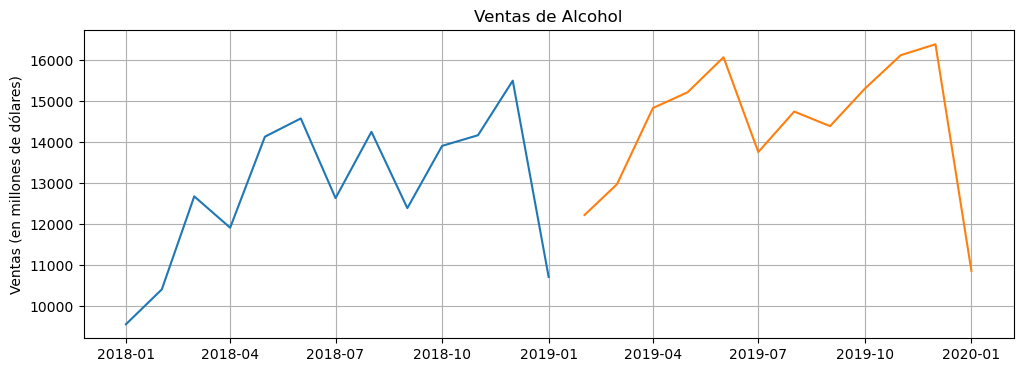

In [33]:
plt.figure(figsize=(12,4))  
plt.title('Ventas de Alcohol') 
plt.ylabel('Ventas (en millones de dólares)') 
plt.grid(True)  

# Graficar datos reales desde enero de 2018 en adelante
plt.plot(df['S4248SM144NCEN']['2018-01-01':])

# Graficar predicciones futuras (excluyendo la ventana utilizada para predicción)
plt.plot(x, true_predictions[window_size:])

plt.show() 